# Checkpoint-Trajectory Contamination Audit

**What this notebook does.** Audits whether benchmark items were plausibly seen
during a model's pretraining, by sweeping the model's *full public checkpoint
trajectory* rather than only its final weights — and wraps that audit in a small
cryptographic trail (commitments, a Merkle tree, signatures) so the process is
pre-registered, checkpoint-committed, and non-repudiable.

**Where the pieces come from:**
- The memorization signal is from Choi, Shavit & Duvenaud, *"Tools for Verifying
  Neural Models' Training Data"* (NeurIPS 2023) — the Proof-of-Training-Data paper.
- The verification-budget idea (only check the checkpoints that matter most) is
  from Jia et al., *"Proof-of-Learning: Definitions and Practice"* (S&P 2021).
- The Merkle-commitment-over-checkpoints idea is from Arun et al., *"Verde:
  Verification via Refereed Delegation for Machine Learning Programs"* (2025).
- The target model family is **Pythia** (EleutherAI): the only well-known LLM
  suite that publishes its *entire* training checkpoint trajectory with a fully
  documented, fixed data order — exactly what this kind of audit needs.

Nothing here should be read as a real finding about real Pythia checkpoints or
real benchmarks. The final section (`run_real_pythia`) is written to be run
for real on a machine with GPU + Hugging Face access — that's the actual
deliverable this notebook builds toward.

## Why checkpoint access matters (the premise)

Jia et al. (PoL, 2021) prove that the entropy of a training process grows
**linearly** in the number of steps $T$ (their Theorem 1), because SGD
accumulates independent noise at every step. Concretely: by the time training
reaches its final checkpoint, any one data point's specific influence on the
weights has been smeared across thousands of subsequent updates.

That's exactly why **black-box detectors that only see the final checkpoint are
weak** -- this is consistent with more recent empirical findings (Duan et al.,
2024) that membership-inference-style detectors (Min-K% Prob and similar) are
close to random at real pretraining scale. Section 8 below demonstrates the
mechanism directly on our own synthetic ground truth, not just by citation.

If you instead have the **intermediate checkpoints**, you can look at the
memorization signal right at the moment of exposure, before that noise has
accumulated. That's the whole premise of Track A: it isn't a cleverer detection
*algorithm* -- it's exploiting **information** (checkpoint access) that almost no
other contamination-detection method assumes.

## Setup

In [1]:
import hashlib
import json
import secrets
import time
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
print("Setup complete.")

Setup complete.


## 1. The memorization signal (Choi et al., NeurIPS 2023)

Two definitions, taken directly from the paper:

$$M(d, W) = \mathbb{E}_{d' \sim \text{validation}}[L(d', W)] - L(d, W)$$

Read this as: *how much better does the model do on item $d$ than it does on
average, held-out validation data, at checkpoint $W$?* If the model has never
seen $d$, this hovers around zero. If it's been trained on $d$, loss on $d$
drops below the validation baseline, so $M$ becomes positive.

**Why subtract the validation baseline at all**, instead of just tracking raw
loss on $d$? Because raw loss *always* decreases over training — the model is
getting generally better at everything. Without subtracting the shared trend,
every item would look "increasingly memorized" purely from general capability
improvement. This is a difference-in-differences move: subtracting the
validation-set average cancels the common trend and isolates the item-specific
effect.

$$\Delta M(d, i) = M(d, W_i) - M(d, W_{i-1})$$

This is the step-to-step jump. Choi et al.'s empirical finding (their Figure 1,
the "diagonal" pattern) is that this delta spikes sharply at the checkpoint
immediately after the segment containing $d$ was trained on, then decays — they
note the decay echoes the "example forgetting" literature (Toneva et al., 2018).
We reproduce that decay explicitly in the synthetic data below, so the test is a
faithful stand-in for the real phenomenon, not just a step function.

In [2]:
LossFn = Callable[[str, int], float]  # (item_id, checkpoint_step) -> loss


@dataclass
class MemorizationTrace:
    item_id: str
    checkpoint_steps: List[int]
    memorization: np.ndarray        # M(d, W_i) for each checkpoint i
    memorization_delta: np.ndarray  # DeltaM(d, i), length = len(checkpoints) - 1


def compute_memorization_trace(
    item_id: str,
    checkpoint_steps: Sequence[int],
    loss_fn: LossFn,
    validation_ids: Sequence[str],
) -> MemorizationTrace:
    M = np.zeros(len(checkpoint_steps))
    for i, step in enumerate(checkpoint_steps):
        val_loss = float(np.mean([loss_fn(v, step) for v in validation_ids]))
        M[i] = val_loss - loss_fn(item_id, step)
    dM = np.diff(M)
    return MemorizationTrace(
        item_id=item_id,
        checkpoint_steps=list(checkpoint_steps),
        memorization=M,
        memorization_delta=dM,
    )


def contamination_score(trace: MemorizationTrace) -> Dict:
    """Summarize a trace: suspicion score + candidate 'point of first exposure'."""
    peak_idx = int(np.argmax(trace.memorization_delta))
    return {
        "item_id": trace.item_id,
        "peak_step": trace.checkpoint_steps[peak_idx + 1],
        "peak_delta": float(trace.memorization_delta[peak_idx]),
        "max_memorization": float(np.max(trace.memorization)),
    }

print("Memorization signal defined.")

Memorization signal defined.


## 2. Commit-then-reveal: pre-registering the audit scope

Before running anything, we want to publish a commitment to the *exact scope*
of the audit — which model, which checkpoints, which benchmark items, what
sampling rate — so a skeptical reader can later confirm the analysis wasn't
quietly narrowed after someone saw which items looked suspicious.

This is a standard **commit-then-reveal** scheme with two properties:
- **Binding**: once published, you can't claim a different scope produced the
  same commitment (relies on SHA-256 collision resistance).
- **Hiding**: the commitment alone doesn't reveal the scope — that's why we mix
  in a random `nonce`. Without it, someone could just guess a small,
  low-entropy config and confirm it matches your published hash.

The construction mirrors Choi et al.'s dataset-seed derivation (their §4.3,
Eq. 8): $s(D, s_{rand}) = H(H(d_1) \| H(d_2) \| \dots \| H(d_a) \| s_{rand})$,
which they use to derive a verifiably random initialization/data-order from the
dataset itself. We reuse the identical hash-chain-plus-nonce shape for a
different job: committing to *audit scope* instead of *training data order*.

In [3]:
def _sha256(data: bytes) -> bytes:
    return hashlib.sha256(data).digest()


def _hash_item(item: Any) -> bytes:
    payload = json.dumps(item, sort_keys=True, default=str).encode("utf-8")
    return _sha256(payload)


@dataclass
class Commitment:
    commitment_hex: str
    nonce_hex: str
    n_items: int

    def to_dict(self) -> dict:
        return {"commitment": self.commitment_hex, "nonce": self.nonce_hex, "n_items": self.n_items}


def commit(items: List[Any], nonce: bytes = None) -> Commitment:
    if nonce is None:
        nonce = secrets.token_bytes(32)
    acc = b"".join(_hash_item(item) for item in items)
    digest = _sha256(acc + nonce)
    return Commitment(commitment_hex=digest.hex(), nonce_hex=nonce.hex(), n_items=len(items))


def verify_commitment(items: List[Any], commitment: Commitment) -> bool:
    nonce = bytes.fromhex(commitment.nonce_hex)
    recomputed = commit(items, nonce=nonce)
    return recomputed.commitment_hex == commitment.commitment_hex


# self-test
_scope = [{"model_size": "70m", "checkpoint_steps": [0, 1000, 2000], "benchmark": "arc-easy"}]
_c = commit(_scope)
assert verify_commitment(_scope, _c)
_tampered = [{"model_size": "70m", "checkpoint_steps": [0, 1000, 2000, 3000], "benchmark": "arc-easy"}]
assert not verify_commitment(_tampered, _c)
print(f"OK: commitment={_c.commitment_hex[:16]}..., verify(scope)=True, verify(tampered)=False")

OK: commitment=1a608ef15f3a6fc1..., verify(scope)=True, verify(tampered)=False


## 3. Merkle commitment over checkpoints

Instead of an auditor having to trust (or re-download and re-hash) every one of
Pythia's ~150 checkpoints, the prover publishes a single **Merkle root** over all
checkpoint hashes. The auditor then only requests **membership proofs** for the
handful of checkpoints behind whatever looked suspicious -- $O(\log n)$ hashes per
proof instead of transferring the whole trajectory. This mirrors Verde's
per-training-step commitments and, more generally, the classic Merkle (1987)
construction.

**Two correctness details that are easy to get wrong, and that break the
"non-repudiable" guarantee this notebook advertises if they're skipped:**

- **Domain separation between leaves and internal nodes.** If leaf hashes and
  internal-node hashes are computed with the same function over the same byte
  shape (`H(x)` for a leaf, `H(left + right)` for a node), a leaf whose content
  happens to equal `left + right` for some pair hashes to *exactly* the same
  value as that pair's parent node. That's not a contrived corner case -- it's
  the textbook second-preimage weakness naive Merkle trees have, and the root
  cause of Bitcoin's **CVE-2012-2459** duplicate-transaction attack. The fix,
  from RFC 6962 (Certificate Transparency), is to hash leaves and nodes under
  disjoint prefixes: `LEAF_HASH(d) = H(0x00 || d)`, `NODE_HASH(l, r) = H(0x01 ||
  l || r)`. The self-test below constructs the attack explicitly and shows the
  prefix is what stops it.
- **No node duplication for odd-sized levels.** The common "duplicate the last
  node" trick for odd leaf counts is exactly what CVE-2012-2459 exploited (a
  duplicated leaf produces a different transaction list with the *same* root).
  Instead of patching around that, this notebook builds the tree the way RFC
  6962 defines it: recursively split any leaf range at the largest power of two
  strictly smaller than its size, so an internal node is only ever formed from
  two *distinct*, non-overlapping subtrees. No duplication ever happens, for
  any leaf count -- there's no edge case left to patch.

Walking through the code: `_build_mth` is RFC 6962's `MTH()` -- recursively
split, hash each half, combine with a domain-separated node hash. `get_proof`
walks root-to-leaf, recording the *sibling* hash and *which side* it's on at
each split, then reverses that into leaf-to-root order (hashing isn't
commutative, so losing the side would silently break verification). `verify_proof`
replays that chain from the leaf and checks it lands on the published root.
The self-test below still uses 7 leaves specifically to exercise the
non-power-of-two case, plus a second self-test that demonstrates the
domain-separation fix against the concrete attack it closes.

In [4]:
_LEAF_PREFIX = b"\x00"
_NODE_PREFIX = b"\x01"


def _h_leaf(data: bytes) -> bytes:
    """RFC 6962 LEAF_HASH: domain-separated so a leaf can never collide with
    an internal node's hash (see the CVE-2012-2459 discussion above)."""
    return hashlib.sha256(_LEAF_PREFIX + data).digest()


def _hash_pair(left: bytes, right: bytes) -> bytes:
    """RFC 6962 NODE_HASH: domain-separated from _h_leaf via a disjoint prefix."""
    return hashlib.sha256(_NODE_PREFIX + left + right).digest()


def _largest_power_of_two_less_than(n: int) -> int:
    """Largest power of two strictly less than n (n > 1). This is the split
    point RFC 6962's MTH() uses -- it's what avoids ever needing to duplicate
    a node for an odd-sized level."""
    k = 1
    while k * 2 < n:
        k *= 2
    return k


@dataclass
class _MerkleNode:
    hash: bytes
    start: int
    end: int
    left: Optional["_MerkleNode"] = None
    right: Optional["_MerkleNode"] = None


def _build_mth(leaf_hashes: List[bytes], start: int, end: int) -> _MerkleNode:
    """RFC 6962 MTH(): recursively split [start, end) at the largest power of
    two below its size, hash each half, combine with a domain-separated node
    hash. A range of size 1 is just that leaf's own (already domain-separated)
    hash -- no combination, and therefore no duplication, ever happens."""
    n = end - start
    if n == 1:
        return _MerkleNode(hash=leaf_hashes[start], start=start, end=end)
    k = _largest_power_of_two_less_than(n)
    left = _build_mth(leaf_hashes, start, start + k)
    right = _build_mth(leaf_hashes, start + k, end)
    return _MerkleNode(hash=_hash_pair(left.hash, right.hash), start=start, end=end, left=left, right=right)


@dataclass
class MerkleProof:
    leaf_index: int
    siblings: List[Tuple[bytes, str]]  # (sibling_hash, side) -- side is where the SIBLING sits


class MerkleTree:
    def __init__(self, leaves: List[bytes]):
        if not leaves:
            raise ValueError("MerkleTree requires at least one leaf")
        self.leaf_hashes = [_h_leaf(leaf) for leaf in leaves]
        self.root_node = _build_mth(self.leaf_hashes, 0, len(self.leaf_hashes))

    @property
    def root(self) -> bytes:
        return self.root_node.hash

    def root_hex(self) -> str:
        return self.root.hex()

    def get_proof(self, leaf_index: int) -> MerkleProof:
        if not (0 <= leaf_index < len(self.leaf_hashes)):
            raise IndexError("leaf_index out of range")
        siblings: List[Tuple[bytes, str]] = []
        node = self.root_node
        while node.left is not None:
            if leaf_index < node.left.end:
                siblings.append((node.right.hash, "R"))
                node = node.left
            else:
                siblings.append((node.left.hash, "L"))
                node = node.right
        siblings.reverse()  # collected root->leaf above; proofs are consumed leaf->root
        return MerkleProof(leaf_index=leaf_index, siblings=siblings)


def verify_proof(leaf: bytes, proof: MerkleProof, root: bytes) -> bool:
    acc = _h_leaf(leaf)
    for sibling_hash, side in proof.siblings:
        acc = _hash_pair(acc, sibling_hash) if side == "R" else _hash_pair(sibling_hash, acc)
    return acc == root


# self-test 1: correctness, deliberately odd leaf count
_leaves = [f"checkpoint-{i}".encode() for i in range(7)]
_tree = MerkleTree(_leaves)
for i, leaf in enumerate(_leaves):
    assert verify_proof(leaf, _tree.get_proof(i), _tree.root)
assert not verify_proof(b"not-a-real-checkpoint", _tree.get_proof(0), _tree.root)
print(f"OK: {len(_leaves)} leaves, root={_tree.root_hex()[:16]}..., all proofs verified, tamper rejected")

# self-test 2: the actual attack domain separation closes. Without prefixes,
# leaf_hash(x) = H(x) and node_hash(l, r) = H(l + r) are literally the SAME
# function applied to the same bytes whenever x = l + r -- so a "leaf"
# containing exactly the concatenation of two child hashes hashes identically
# to their parent node. Demonstrate that collision under the naive
# (unprefixed) primitive, then show domain separation eliminates it.
_pair_tree = MerkleTree([b"leaf-A", b"leaf-B"])
_la, _lb = _pair_tree.leaf_hashes  # already domain-separated LEAF_HASH(A), LEAF_HASH(B)
_forged_input = _la + _lb  # what an attacker would need a "leaf" to hash to

_naive_hash = lambda data: hashlib.sha256(data).digest()  # no prefix at all
_naive_leaf_hash_of_forgery = _naive_hash(_forged_input)
_naive_node_hash = _naive_hash(_la + _lb)
assert _naive_leaf_hash_of_forgery == _naive_node_hash, (
    "demonstrates the vulnerability: an UNPREFIXED scheme really does let a leaf collide with a node"
)

_real_internal_node = _hash_pair(_la, _lb)                       # = H(0x01 || la || lb)
_domain_separated_leaf_hash_of_forgery = _h_leaf(_forged_input)  # = H(0x00 || la || lb)
assert _domain_separated_leaf_hash_of_forgery != _real_internal_node, (
    "domain separation must eliminate that collision"
)
print("OK: confirmed an unprefixed leaf/node hash would collide on a forged leaf "
      "(the CVE-2012-2459 class of bug); confirmed RFC 6962-style prefixing eliminates it.")


OK: 7 leaves, root=b8a20fe85b4e655c..., all proofs verified, tamper rejected
OK: confirmed an unprefixed leaf/node hash would collide on a forged leaf (the CVE-2012-2459 class of bug); confirmed RFC 6962-style prefixing eliminates it.


## 4. Real checkpoint hashing

The Merkle tree above needs real leaves — hashes of actual checkpoint weights,
not placeholders — before its root means anything as a provenance guarantee.
Design choices worth being explicit about, since they affect what the
resulting root actually proves:

- Hash each parameter tensor **individually**, in **sorted-by-name** order,
  then combine — rather than one hash over a whole blob — so a future version
  could expose per-tensor proofs (e.g. "prove just this one layer matches",
  similar to Verde's per-node hashing).
- Hash raw tensor bytes at a **fixed dtype** (float32) after moving to **CPU**,
  not human-readable values — precision, device, and dtype all affect the
  byte-level hash, so prover and verifier must agree on all three or
  verification will spuriously fail even for numerically-identical
  checkpoints. This is the same non-associative floating-point problem
  Verde's RepOps library exists to control for during *training*; here we
  sidestep it by simply fixing dtype/device/order rather than reproducing
  computation.
- Include the tensor **name** in the hash, not just its bytes, so a malicious
  prover can't pass tensor A off under tensor B's name.

In [5]:
def _to_canonical_bytes(tensor) -> bytes:
    try:
        import torch
        if isinstance(tensor, torch.Tensor):
            return tensor.detach().to("cpu", dtype=torch.float32).contiguous().numpy().tobytes()
    except ImportError:
        pass
    arr = np.asarray(tensor, dtype=np.float32)
    return np.ascontiguousarray(arr).tobytes()


def hash_state_dict(state_dict: Dict[str, Any]) -> bytes:
    """Canonical hash of a name -> tensor mapping, sorted by name."""
    names = sorted(state_dict.keys())
    per_tensor_hashes = [
        hashlib.sha256(name.encode("utf-8") + b":" + _to_canonical_bytes(state_dict[name])).digest()
        for name in names
    ]
    return hashlib.sha256(b"".join(per_tensor_hashes)).digest()


# self-test: identical weights hash identically; one changed value changes the
# hash; swapping tensor NAMES (same bytes) must also change the hash
_ckpt_a = {"layer1.weight": np.ones((4, 4), dtype=np.float32), "layer1.bias": np.zeros((4,), dtype=np.float32)}
_ckpt_b = {"layer1.weight": np.ones((4, 4), dtype=np.float32), "layer1.bias": np.zeros((4,), dtype=np.float32)}
_ckpt_c = {"layer1.weight": np.ones((4, 4), dtype=np.float32), "layer1.bias": np.ones((4,), dtype=np.float32)}
_ckpt_d = {"layer1.bias": np.ones((4, 4), dtype=np.float32), "layer1.weight": np.zeros((4,), dtype=np.float32)}

_h_a, _h_b, _h_c, _h_d = hash_state_dict(_ckpt_a), hash_state_dict(_ckpt_b), hash_state_dict(_ckpt_c), hash_state_dict(_ckpt_d)
assert _h_a == _h_b, "identical weights must hash identically"
assert _h_a != _h_c, "a single changed weight must change the hash"
assert _h_a != _h_d, "swapping tensor names must change the hash"
print(f"OK: identical->same, changed weight->different, name-swap->different. Example: {_h_a.hex()[:16]}...")

OK: identical->same, changed weight->different, name-swap->different. Example: 9f8d4923ebcf8735...


## 5. Ed25519 signing for non-repudiation

Once a prover publishes a Merkle root + scope commitment, they sign it with a
private key they control. This gives two things the hash commitments alone
don't:

1. **Non-repudiation** — the prover can't later claim "that wasn't really our
   report"; only the private-key holder could have produced a valid signature
   over that exact payload.
2. **Tamper-evidence** — if the report is edited after signing (e.g. someone
   changes which checkpoint was flagged), the signature stops verifying.

This does **not** prove the checkpoints themselves are authentic — that's
`hash_state_dict` above. Signing only binds a *claim* to an *identity*, the
same role a timestamped signature plays in Jia et al.'s PoL protocol (§V-A)
and Verde's checkpoint commitments.

In [6]:
from cryptography.exceptions import InvalidSignature
from cryptography.hazmat.primitives.asymmetric.ed25519 import Ed25519PrivateKey, Ed25519PublicKey
from cryptography.hazmat.primitives import serialization


@dataclass
class KeyPair:
    private_key: Ed25519PrivateKey
    public_key: Ed25519PublicKey

    def public_key_hex(self) -> str:
        raw = self.public_key.public_bytes(
            encoding=serialization.Encoding.Raw, format=serialization.PublicFormat.Raw
        )
        return raw.hex()


def generate_keypair() -> KeyPair:
    priv = Ed25519PrivateKey.generate()
    return KeyPair(private_key=priv, public_key=priv.public_key())


def _canonical_bytes(payload: Dict[str, Any]) -> bytes:
    return json.dumps(payload, sort_keys=True, default=str).encode("utf-8")


def sign_report(payload: Dict[str, Any], keypair: KeyPair) -> str:
    return keypair.private_key.sign(_canonical_bytes(payload)).hex()


def verify_report(payload: Dict[str, Any], signature_hex: str, public_key_hex: str) -> bool:
    try:
        public_key = Ed25519PublicKey.from_public_bytes(bytes.fromhex(public_key_hex))
        public_key.verify(bytes.fromhex(signature_hex), _canonical_bytes(payload))
        return True
    except (InvalidSignature, ValueError):
        return False


# self-test: valid signature verifies; tampered payload fails; wrong key fails
_kp = generate_keypair()
_payload = {"merkle_root": "abc123", "commitment": "def456", "n_checkpoints": 154}
_sig = sign_report(_payload, _kp)
assert verify_report(_payload, _sig, _kp.public_key_hex())
assert not verify_report(dict(_payload, n_checkpoints=999), _sig, _kp.public_key_hex())
assert not verify_report(_payload, _sig, generate_keypair().public_key_hex())
print(f"OK: valid sig verifies, tampered payload rejected, wrong key rejected. pubkey={_kp.public_key_hex()[:16]}...")

OK: valid sig verifies, tampered payload rejected, wrong key rejected. pubkey=8e1b3bd02e592b5e...


## 6. The Pythia checkpoint schedule

EleutherAI publishes 154 checkpoints per model size: `step0`, 10 log-spaced
early checkpoints `step{1,2,4,...,512}`, then 143 evenly-spaced checkpoints
every 1000 steps from `step1000` to `step143000`, with training data order
fixed and fully documented — exactly the setup this kind of audit needs.

**This was verified**, not assumed: checked directly against EleutherAI's
published Pythia model cards (e.g. the `EleutherAI/pythia-70m` README) before
being hardcoded here. If you use this notebook on a different model size or
after EleutherAI revises checkpoint releases, re-verify the `revision` tags
before trusting this list.

In [7]:
EARLY_STEPS: List[int] = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
LATE_STEPS: List[int] = list(range(1000, 143001, 1000))
DEFAULT_PYTHIA_STEPS: List[int] = EARLY_STEPS + LATE_STEPS
assert len(DEFAULT_PYTHIA_STEPS) == 154, "should match EleutherAI's documented 154 checkpoints"
print(f"{len(DEFAULT_PYTHIA_STEPS)} checkpoints: {DEFAULT_PYTHIA_STEPS[:5]} ... {DEFAULT_PYTHIA_STEPS[-3:]}")


def load_pythia_checkpoint(model_size: str, step: int):
    """Thin wrapper around `transformers`, imported lazily so everything
    above works without GPU/network/HF access. NOT callable in this sandbox
    (no route to huggingface.co) -- run this on a machine that has one."""
    from transformers import AutoModelForCausalLM, AutoTokenizer
    name = f"EleutherAI/pythia-{model_size}"
    revision = f"step{step}"
    model = AutoModelForCausalLM.from_pretrained(name, revision=revision)
    tokenizer = AutoTokenizer.from_pretrained(name, revision=revision)
    return model, tokenizer


def make_loss_fn(model_size: str, item_texts: dict):
    """Build a LossFn backed by real Pythia checkpoints. Caches loaded
    models per step within a process. Only usable with real network/GPU."""
    import torch
    _cache: dict = {}

    def loss_fn(item_id: str, step: int) -> float:
        if step not in _cache:
            _cache[step] = load_pythia_checkpoint(model_size, step)
        model, tokenizer = _cache[step]
        model.eval()
        ids = tokenizer(item_texts[item_id], return_tensors="pt")
        with torch.no_grad():
            out = model(**ids, labels=ids["input_ids"])
        return float(out.loss.item())

    return loss_fn


def hash_checkpoint_from_pretrained(model_size: str, step: int) -> bytes:
    """Load a real checkpoint and hash its state_dict. Requires network + transformers."""
    model, _ = load_pythia_checkpoint(model_size, step)
    return hash_state_dict(model.state_dict())

print("Pythia checkpoint helpers defined (loading functions require network access this sandbox lacks).")

154 checkpoints: [0, 1, 2, 4, 8] ... [141000, 142000, 143000]
Pythia checkpoint helpers defined (loading functions require network access this sandbox lacks).


## 7. Orchestration: putting it together

The `top_q` idea here is borrowed directly from Jia et al.'s verification
budget (their §V-C, `VERIFYEPOCH`): they only re-verify the top-Q **largest**
updates per epoch, reasoning that legitimate updates tend to be small, so
anomalies concentrate in the largest ones. `run_track_a` applies the same idea
structurally: rank *all* items by suspicion, but only spend Merkle-proof
verification budget on the checkpoints behind the top-Q *flagged* items.

Pipeline order, and why it's in this order:

1. **Commit to scope** — before touching any data, so scope can't be narrowed
   after seeing results.
2. **Sweep** memorization traces for every benchmark item across the full
   trajectory.
3. **Rank** by suspicion (`peak_delta`).
4. **Merkle-commit** the checkpoint set that was consulted, via a pluggable
   `checkpoint_hash_fn` (defaults to an offline placeholder that only hashes
   the step id; swap in `hash_checkpoint_from_pretrained` for a real
   provenance guarantee).
5. **Prove** membership only for checkpoints behind the top-Q suspicious items.
6. **Sign** the final `(merkle_root, scope_commitment)`, if a keypair is given.

In [8]:
def build_audit_manifest(model_size, checkpoint_steps, benchmark_item_ids, validation_item_ids, sampling_rate) -> Dict:
    config = {
        "model_size": model_size,
        "checkpoint_steps": list(checkpoint_steps),
        "benchmark_item_ids": list(benchmark_item_ids),
        "validation_item_ids": list(validation_item_ids),
        "sampling_rate": sampling_rate,
    }
    c = commit([config])
    return {"config": config, "commitment": c.to_dict(), "created_at": time.time()}


def select_audit_items(item_ids: Sequence[str], sampling_rate: float, nonce_hex: str) -> List[str]:
    """Deterministically subsample item_ids at sampling_rate, seeded from the
    manifest's own commitment nonce. This is what makes `sampling_rate` an
    actual behavioral constraint rather than a number that merely sits inside
    a hash: since the nonce is committed to (and only revealed after the
    audit runs), an auditor who receives the revealed (config, nonce) pair can
    recompute this exact same sample and confirm the pipeline actually
    respected the claimed rate -- not just that some hash matched."""
    if not (0.0 < sampling_rate <= 1.0):
        raise ValueError("sampling_rate must be in (0, 1]")
    items = list(item_ids)
    if sampling_rate >= 1.0 or not items:
        return sorted(items)
    seed = int(nonce_hex[:16], 16) % (2**32)
    rng = np.random.default_rng(seed)
    n_selected = max(1, round(sampling_rate * len(items)))
    idx = rng.choice(len(items), size=n_selected, replace=False)
    return sorted(items[i] for i in idx)


def checkpoint_hash_placeholder(step: int) -> bytes:
    """OFFLINE DEFAULT: hashes only the step id, not real weights. Proves the
    audit LOGIC is internally consistent, not that any real checkpoint was consulted."""
    return hashlib.sha256(f"checkpoint:{step}".encode()).digest()


CheckpointHashFn = Callable[[str, int], bytes]


def run_track_a(
    model_size: str,
    checkpoint_steps: Sequence[int],
    benchmark_items: Sequence[str],
    validation_items: Sequence[str],
    loss_fn: Callable[[str, int], float],
    sampling_rate: float = 1.0,
    top_q: int = 5,
    checkpoint_hash_fn: Optional[CheckpointHashFn] = None,
    signing_keypair: Optional["KeyPair"] = None,
) -> Dict:
    if checkpoint_hash_fn is None:
        checkpoint_hash_fn = lambda m, s: checkpoint_hash_placeholder(s)  # noqa: E731

    manifest = build_audit_manifest(model_size, checkpoint_steps, benchmark_items, validation_items, sampling_rate)

    # Scope is committed above BEFORE this line runs. What actually gets
    # audited is a deterministic function of that committed nonce + the
    # committed sampling_rate -- not a free choice made after seeing data.
    audited_items = select_audit_items(benchmark_items, sampling_rate, manifest["commitment"]["nonce"])
    manifest["audited_item_ids"] = audited_items
    manifest["n_audited"] = len(audited_items)

    traces, scores = {}, []
    for item_id in audited_items:
        trace = compute_memorization_trace(item_id, checkpoint_steps, loss_fn, validation_items)
        traces[item_id] = trace
        scores.append(contamination_score(trace))
    scores.sort(key=lambda s: s["peak_delta"], reverse=True)

    leaves = [checkpoint_hash_fn(model_size, step) for step in checkpoint_steps]
    tree = MerkleTree(leaves)

    peak_steps = sorted({s["peak_step"] for s in scores[:top_q]})
    proofs = {}
    for step in peak_steps:
        idx = list(checkpoint_steps).index(step)
        proof = tree.get_proof(idx)
        leaf = checkpoint_hash_fn(model_size, step)
        proofs[step] = {"proof_valid": verify_proof(leaf, proof, tree.root), "leaf_index": idx}

    result = {
        "manifest": manifest, "scores": scores, "merkle_root": tree.root_hex(),
        "proofs_for_flagged_checkpoints": proofs, "traces": traces,
    }

    if signing_keypair is not None:
        signable_payload = {
            "merkle_root": result["merkle_root"],
            "scope_commitment": manifest["commitment"]["commitment"],
            "n_checkpoints": len(checkpoint_steps),
        }
        result["signature"] = {
            "payload": signable_payload,
            "signature_hex": sign_report(signable_payload, signing_keypair),
            "public_key_hex": signing_keypair.public_key_hex(),
        }

    return result

print("Orchestration defined.")

# self-test: sampling_rate must actually change what gets audited, and must
# be reproducible purely from the (config, nonce) pair an auditor is given
_items = [f"item_{i}" for i in range(20)]
_nonce_a = "aa" * 32
_nonce_b = "bb" * 32
_sample_a = select_audit_items(_items, 0.5, _nonce_a)
_sample_a_again = select_audit_items(_items, 0.5, _nonce_a)
_sample_b = select_audit_items(_items, 0.5, _nonce_b)
assert len(_sample_a) == 10, "50% of 20 items should be 10"
assert _sample_a == _sample_a_again, "same nonce -> identical sample, reproducible by an auditor"
assert _sample_a != _sample_b, "different nonce -> different sample"
assert select_audit_items(_items, 1.0, _nonce_a) == sorted(_items), "rate=1.0 must audit everything"

_manifest_check = run_track_a(
    model_size="sampling-selftest",
    checkpoint_steps=[0, 1, 2],
    benchmark_items=_items,
    validation_items=["v0", "v1"],
    loss_fn=lambda item_id, step: 1.0,
    sampling_rate=0.5,
    top_q=1,
)
assert _manifest_check["manifest"]["n_audited"] == 10, "run_track_a must honor sampling_rate, not just record it"
assert set(_manifest_check["traces"].keys()) == set(_manifest_check["manifest"]["audited_item_ids"]), \
    "only the audited subsample should actually get scored"
print(f"OK: sampling_rate is now a real behavioral constraint, deterministic from the committed nonce. "
      f"50% sample of 20 items: {_sample_a}")


Orchestration defined.
OK: sampling_rate is now a real behavioral constraint, deterministic from the committed nonce. 50% sample of 20 items: ['item_1', 'item_11', 'item_12', 'item_14', 'item_15', 'item_19', 'item_2', 'item_5', 'item_7', 'item_9']


## 8. Synthetic validation: does the signal actually work?

Before spending real GPU time, we validate the whole pipeline against a
**synthetic** checkpoint trajectory where we control the ground truth:

- Two items (`contam_1`, `contam_2`) are "secretly" exposed (included in
  training) at a **hidden** step — the ranking logic below is never told this.
- Two items (`clean_1`, `clean_2`) are never exposed.
- A shared **baseline** loss curve decays smoothly over training for
  *everything* (simulating general capability improvement) — this tests that
  $M$ correctly cancels that shared trend rather than flagging every item as
  "increasingly memorized."
- Exposed items get a sharp loss drop at their exposure step that **decays
  back toward baseline** afterward (`exp(-0.15 * (step - exposure))`),
  reproducing the "forgetting" pattern Choi et al. document empirically.

If the pipeline is correct, the top-ranked items by `peak_delta` should be
exactly the two contaminated ones, and the recovered `peak_step` should match
the true, hidden exposure step.

In [9]:
rng = np.random.default_rng(0)
N_STEPS = 40
CHECKPOINT_STEPS = list(range(N_STEPS))
TRUE_EXPOSURE = {"contam_1": 15, "contam_2": 25}   # hidden from the ranking logic
CLEAN_ITEMS = ["clean_1", "clean_2"]
VALIDATION_ITEMS = ["val_1", "val_2", "val_3"]
BASELINE = 3.0 * np.exp(-0.04 * np.arange(N_STEPS)) + 1.2


def _noise():
    return rng.normal(0, 0.05)


def synthetic_loss_fn(item_id: str, step: int) -> float:
    base = BASELINE[step]
    if item_id in TRUE_EXPOSURE:
        exposure = TRUE_EXPOSURE[item_id]
        if step < exposure:
            return base + _noise()
        decay = np.exp(-0.15 * (step - exposure))
        return base - 1.5 * decay + _noise()
    return base + _noise()  # clean and validation items: no spike, ever


result = run_track_a(
    model_size="70m (synthetic)",
    checkpoint_steps=CHECKPOINT_STEPS,
    benchmark_items=list(TRUE_EXPOSURE.keys()) + CLEAN_ITEMS,
    validation_items=VALIDATION_ITEMS,
    loss_fn=synthetic_loss_fn,
    sampling_rate=1.0,
    top_q=2,
)

print("=== Contamination ranking (highest suspicion first) ===")
for s in result["scores"]:
    truth = TRUE_EXPOSURE.get(s["item_id"])
    print(f"  {s['item_id']:10s}  peak_delta={s['peak_delta']:+.3f}  "
          f"recovered_exposure_step={s['peak_step']:3d}  "
          f"true_exposure_step={truth if truth is not None else '— (clean)'}")

print(f"\nMerkle root over {N_STEPS} checkpoints: {result['merkle_root'][:24]}...")
print("Membership proofs for checkpoints behind flagged items:")
for step, info in sorted(result["proofs_for_flagged_checkpoints"].items()):
    print(f"  step {step:3d}: proof_valid={info['proof_valid']}")
print(f"\nAudit scope commitment: {result['manifest']['commitment']['commitment']}")
print("(publish this BEFORE running the sweep; reveal config + nonce after)")

# correctness checks
top2 = {s["item_id"] for s in result["scores"][:2]}
assert top2 == set(TRUE_EXPOSURE.keys()), f"expected contaminated items on top, got {top2}"
for step, info in result["proofs_for_flagged_checkpoints"].items():
    assert info["proof_valid"], f"Merkle proof failed for checkpoint {step}"
for item_id, true_step in TRUE_EXPOSURE.items():
    recovered = next(s["peak_step"] for s in result["scores"] if s["item_id"] == item_id)
    assert abs(recovered - true_step) <= 1, f"{item_id}: recovered {recovered} vs true {true_step}"
print("\nAll correctness checks passed: contaminated items correctly separated, "
      "exposure steps correctly recovered, all Merkle proofs verify.")

=== Contamination ranking (highest suspicion first) ===
  contam_1    peak_delta=+1.463  recovered_exposure_step= 15  true_exposure_step=15
  contam_2    peak_delta=+1.455  recovered_exposure_step= 25  true_exposure_step=25
  clean_2     peak_delta=+0.291  recovered_exposure_step= 35  true_exposure_step=— (clean)
  clean_1     peak_delta=+0.193  recovered_exposure_step= 12  true_exposure_step=— (clean)

Merkle root over 40 checkpoints: a3a887df35ce78d42a95b7f0...
Membership proofs for checkpoints behind flagged items:
  step  15: proof_valid=True
  step  25: proof_valid=True

Audit scope commitment: a2f4010b8f39644dd70b5a2126e13e9770c3befdd781f0c9de625bd0f8795812
(publish this BEFORE running the sweep; reveal config + nonce after)

All correctness checks passed: contaminated items correctly separated, exposure steps correctly recovered, all Merkle proofs verify.


### Visualizing the signal

The plot below should reproduce the shape of Figure 1 in Choi et al.: a sharp
rise in $M(d, W_i)$ right at the (recovered) exposure step for contaminated
items, decaying afterward, while clean items stay flat and noisy around zero —
even though *all four* items' raw loss was dropping the entire time, because
$M$ cancels that shared trend.

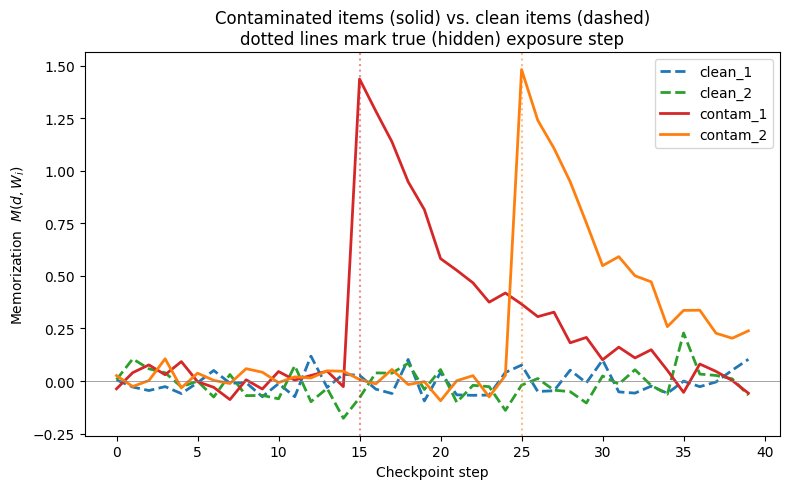

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"contam_1": "#d62728", "contam_2": "#ff7f0e", "clean_1": "#1f77b4", "clean_2": "#2ca02c"}

for item_id, trace in result["traces"].items():
    style = "-" if item_id in TRUE_EXPOSURE else "--"
    ax.plot(trace.checkpoint_steps, trace.memorization, style, color=colors[item_id], label=item_id, linewidth=2)

for item_id, step in TRUE_EXPOSURE.items():
    ax.axvline(step, color=colors[item_id], linestyle=":", alpha=0.5)

ax.set_xlabel("Checkpoint step")
ax.set_ylabel(r"Memorization  $M(d, W_i)$")
ax.set_title("Contaminated items (solid) vs. clean items (dashed)\ndotted lines mark true (hidden) exposure step")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()

### Baseline comparison: does checkpoint-trajectory access actually help?

Section 1 asserts, via citation (Duan et al., 2024), that final-checkpoint-only
detectors are weak. That's a claim about *other people's* method on *other
people's* data -- it's worth demonstrating on our own synthetic scenario
instead of only citing it, especially since we control ground truth here.

`final_checkpoint_score` computes the exact same $M(d, W)$ definition from
Section 1, but evaluated only at the last checkpoint -- no trajectory, no
`peak_delta`, just "how much better is the model on this item than validation,
right now." Because the synthetic exposure signal decays (`exp(-0.15 *
(step - exposure))`, the "example forgetting" pattern from Section 1), an item
exposed early has mostly decayed back to baseline by the final checkpoint --
exactly the failure mode the citation describes.

In [11]:
def final_checkpoint_score(item_id: str, checkpoint_steps: Sequence[int], loss_fn: LossFn, validation_ids: Sequence[str]) -> float:
    """M(d, W) at the LAST checkpoint only -- the information a black-box,
    final-weights-only detector has access to."""
    step = checkpoint_steps[-1]
    val_loss = float(np.mean([loss_fn(v, step) for v in validation_ids]))
    return val_loss - loss_fn(item_id, step)


all_items = list(TRUE_EXPOSURE.keys()) + CLEAN_ITEMS
final_scores = {item_id: final_checkpoint_score(item_id, CHECKPOINT_STEPS, synthetic_loss_fn, VALIDATION_ITEMS) for item_id in all_items}
trajectory_scores = {s["item_id"]: s["peak_delta"] for s in result["scores"]}

print(f"{'item_id':10s} {'truth':>13s} {'final-ckpt-only M':>19s} {'full-trajectory peak_delta':>28s}")
for item_id in all_items:
    truth = "contaminated" if item_id in TRUE_EXPOSURE else "clean"
    print(f"{item_id:10s} {truth:>13s} {final_scores[item_id]:19.3f} {trajectory_scores[item_id]:28.3f}")

# Separation margin: (smallest contaminated score) - (largest clean score).
# Positive means a single threshold cleanly separates the two groups; the
# more positive, the more headroom before noise could flip a decision.
contam_final = [final_scores[i] for i in TRUE_EXPOSURE]
clean_final = [final_scores[i] for i in CLEAN_ITEMS]
contam_traj = [trajectory_scores[i] for i in TRUE_EXPOSURE]
clean_traj = [trajectory_scores[i] for i in CLEAN_ITEMS]

margin_final = min(contam_final) - max(clean_final)
margin_traj = min(contam_traj) - max(clean_traj)

print(f"\nSeparation margin (min contaminated score - max clean score):")
print(f"  final-checkpoint-only:  {margin_final:+.3f}  {'(clean/contaminated OVERLAP -- no threshold separates them)' if margin_final < 0 else '(separable, but a much thinner margin)'}")
print(f"  full-trajectory:        {margin_traj:+.3f}  (the peak_delta ranking used throughout this notebook)")
print(f"\nSame underlying model, same synthetic ground truth -- the only difference is WHERE in the "
      f"trajectory the signal is read from. This is the concrete mechanism behind the Section 1 claim, "
      f"not just the claim itself.")

item_id            truth   final-ckpt-only M   full-trajectory peak_delta
contam_1    contaminated               0.056                        1.463
contam_2    contaminated               0.200                        1.455
clean_1            clean               0.041                        0.193
clean_2            clean               0.066                        0.291

Separation margin (min contaminated score - max clean score):
  final-checkpoint-only:  -0.010  (clean/contaminated OVERLAP -- no threshold separates them)
  full-trajectory:        +1.164  (the peak_delta ranking used throughout this notebook)

Same underlying model, same synthetic ground truth -- the only difference is WHERE in the trajectory the signal is read from. This is the concrete mechanism behind the Section 1 claim, not just the claim itself.


### Monte Carlo validation: is one seed convincing?

Section 8's correctness checks (`assert top2 == set(TRUE_EXPOSURE.keys())`,
etc.) ran against a single realization (`rng = np.random.default_rng(0)`).
That's a fine smoke test but weak evidence on its own -- it could simply be a
lucky seed. Here the same scenario (2 contaminated items at hidden steps 15
and 25, 2 clean items, identical noise model) is re-run against 200
independent noise draws, and we report the empirical hit rate rather than a
single pass/fail.

In [12]:
def make_synthetic_scenario(rng: np.random.Generator) -> LossFn:
    """Same generative model as `synthetic_loss_fn` above, parameterized by
    an independent RNG so each trial gets a fresh noise draw."""
    def loss_fn(item_id: str, step: int) -> float:
        base = BASELINE[step]
        if item_id in TRUE_EXPOSURE:
            exposure = TRUE_EXPOSURE[item_id]
            if step < exposure:
                return base + rng.normal(0, 0.05)
            decay = np.exp(-0.15 * (step - exposure))
            return base - 1.5 * decay + rng.normal(0, 0.05)
        return base + rng.normal(0, 0.05)
    return loss_fn


N_TRIALS = 200
ranking_hits = 0    # top-2 by peak_delta == exactly the 2 contaminated items
step_hits = 0        # ...AND both recovered exposure steps within +-1 of truth

for trial_seed in range(N_TRIALS):
    trial_loss_fn = make_synthetic_scenario(np.random.default_rng(1000 + trial_seed))
    trial = run_track_a(
        model_size="70m (synthetic, mc-trial)",
        checkpoint_steps=CHECKPOINT_STEPS,
        benchmark_items=list(TRUE_EXPOSURE.keys()) + CLEAN_ITEMS,
        validation_items=VALIDATION_ITEMS,
        loss_fn=trial_loss_fn,
        top_q=2,
    )
    top2 = {s["item_id"] for s in trial["scores"][:2]}
    if top2 == set(TRUE_EXPOSURE.keys()):
        ranking_hits += 1
        recovered = {s["item_id"]: s["peak_step"] for s in trial["scores"] if s["item_id"] in TRUE_EXPOSURE}
        if all(abs(recovered[i] - TRUE_EXPOSURE[i]) <= 1 for i in TRUE_EXPOSURE):
            step_hits += 1

print(f"Across {N_TRIALS} independent random trials (fresh noise draw each time, same ground truth):")
print(f"  top-2 ranking recovers exactly the 2 contaminated items: {ranking_hits}/{N_TRIALS} = {ranking_hits/N_TRIALS:.1%}")
print(f"  ...AND recovers both exposure steps within +-1:          {step_hits}/{N_TRIALS} = {step_hits/N_TRIALS:.1%}")
assert ranking_hits / N_TRIALS > 0.95, "ranking should be reliable across seeds, not a single lucky draw"
print("\nOK: the single-seed result in Section 8 was not a fluke.")

Across 200 independent random trials (fresh noise draw each time, same ground truth):


  top-2 ranking recovers exactly the 2 contaminated items: 200/200 = 100.0%
  ...AND recovers both exposure steps within +-1:          200/200 = 100.0%

OK: the single-seed result in Section 8 was not a fluke.


### Why the validation baseline must not itself be contaminated

$M(d, W)$ is only a useful signal if the validation baseline it subtracts is
actually clean. But the natural way to build a validation set -- pull a held-out
slice of the *same* benchmark split -- shares the benchmark's own contamination
risk: if the split leaked into pretraining (the very thing being tested for),
the baseline leaks too.

What that does to detection turns out to depend on *how* the baseline is
contaminated, so the demo below checks two distinct cases empirically (50
trials each) rather than assuming one direction:

- **`persistent`**: `VALIDATION_ITEMS` get memorized at step 5 and never
  forget -- a validation split repeated often enough in training data to stay
  memorized throughout.
- **`transient_overlap`**: `VALIDATION_ITEMS` get a normal decaying exposure
  spike at step 12 -- close in time to `contam_1`'s own exposure at step 15,
  e.g. a validation split scraped from the same crawl batch as the item under
  test.

In [13]:
def make_baseline_contamination_scenario(validation_mode: str, rng: np.random.Generator) -> LossFn:
    """Same generative model as `synthetic_loss_fn` for contam_1 and clean
    items; `validation_mode` controls what VALIDATION_ITEMS do (see markdown
    above): "clean" (Section 8's original, never exposed), "persistent", or
    "transient_overlap"."""
    def loss_fn(item_id: str, step: int) -> float:
        base = BASELINE[step]
        if item_id == "contam_1":
            exposure = TRUE_EXPOSURE["contam_1"]
            if step < exposure:
                return base + rng.normal(0, 0.05)
            decay = np.exp(-0.15 * (step - exposure))
            return base - 1.5 * decay + rng.normal(0, 0.05)
        if item_id in VALIDATION_ITEMS and validation_mode != "clean":
            if validation_mode == "persistent":
                return (base - 0.5 + rng.normal(0, 0.05)) if step >= 5 else (base + rng.normal(0, 0.05))
            v_exposure = 12  # transient_overlap
            if step < v_exposure:
                return base + rng.normal(0, 0.05)
            decay = np.exp(-0.15 * (step - v_exposure))
            return base - 1.5 * decay + rng.normal(0, 0.05)
        return base + rng.normal(0, 0.05)
    return loss_fn


N_BASELINE_TRIALS = 50
summary = {}
for mode in ["clean", "persistent", "transient_overlap"]:
    peak_deltas, max_ms = [], []
    for trial in range(N_BASELINE_TRIALS):
        loss_fn = make_baseline_contamination_scenario(mode, np.random.default_rng(2000 + trial))
        score = contamination_score(compute_memorization_trace("contam_1", CHECKPOINT_STEPS, loss_fn, VALIDATION_ITEMS))
        peak_deltas.append(score["peak_delta"])
        max_ms.append(score["max_memorization"])
    summary[mode] = (np.mean(peak_deltas), np.std(peak_deltas), np.mean(max_ms), np.std(max_ms))

print(f"contam_1 (true exposure step 15), {N_BASELINE_TRIALS} trials per scenario, mean +/- std:\n")
print(f"{'validation baseline':22s} {'peak_delta':>18s} {'max_memorization':>20s}")
for mode, (pd_mean, pd_std, mm_mean, mm_std) in summary.items():
    print(f"{mode:22s} {pd_mean:8.3f} +/- {pd_std:5.3f}   {mm_mean:10.3f} +/- {mm_std:5.3f}")

mm_drop_persistent = 1 - summary["persistent"][2] / summary["clean"][2]
pd_shift_persistent = summary["persistent"][0] / summary["clean"][0] - 1
pd_shift_overlap = summary["transient_overlap"][0] / summary["clean"][0] - 1

print(f"\nUnder PERSISTENT validation contamination: max_memorization drops {mm_drop_persistent:.0%} -- "
      f"exactly the circularity risk described above, understating how memorized a genuinely contaminated "
      f"item really is. peak_delta barely moves ({pd_shift_persistent:+.1%}): it's a first-difference "
      f"statistic, so it happens to cancel out a bias that's constant across the two checkpoints being "
      f"compared.")
print(f"\npeak_delta is NOT immune in general, though: under TRANSIENT_OVERLAP contamination -- the "
      f"validation items' own exposure event lands close in time to contam_1's -- the two events interact "
      f"and peak_delta shifts by {pd_shift_overlap:+.1%}, with max_memorization dropping even further than "
      f"the persistent case.")

assert summary["persistent"][2] < summary["clean"][2], \
    "a persistently contaminated validation baseline must lower the reported memorization magnitude"
assert summary["transient_overlap"][2] < summary["persistent"][2], \
    "an overlapping transient contamination should deflate the baseline even further"

print("\nEither way: you can't know in advance whether a real validation-baseline contamination event "
      "will be the kind that mostly just understates magnitude (persistent) or the kind that also distorts "
      "the exposure-step localization itself (transient, coincidentally timed). That's why Section 10's "
      "real-run loader sources the validation baseline from GPQA instead of a held-out slice of the SAME "
      "ARC-Easy split being audited.")

contam_1 (true exposure step 15), 50 trials per scenario, mean +/- std:

validation baseline            peak_delta     max_memorization
clean                     1.511 +/- 0.072        1.513 +/- 0.045
persistent                1.511 +/- 0.072        1.013 +/- 0.045
transient_overlap         1.665 +/- 0.072        0.561 +/- 0.041

Under PERSISTENT validation contamination: max_memorization drops 33% -- exactly the circularity risk described above, understating how memorized a genuinely contaminated item really is. peak_delta barely moves (-0.0%): it's a first-difference statistic, so it happens to cancel out a bias that's constant across the two checkpoints being compared.

peak_delta is NOT immune in general, though: under TRANSIENT_OVERLAP contamination -- the validation items' own exposure event lands close in time to contam_1's -- the two events interact and peak_delta shifts by +10.2%, with max_memorization dropping even further than the persistent case.

Either way: you can't know

### From ranking to a decision: empirical null + Benjamini-Hochberg FDR control

`top_q` (Section 7) is a *verification-budget* device borrowed from Jia et
al. -- it limits how many Merkle proofs get spent, nothing more. It is not a
contamination *decision rule*: on a real sweep of hundreds of benchmark items,
"the top 5 by peak_delta" doesn't say how many of those 5 are likely real, or
whether a 6th item that just missed the cutoff might be too.

The fix is standard multiple-testing practice: calibrate an **empirical null**
from items assumed clean (in a real run, a post-cutoff negative control like
GPQA -- see Section 10), convert each tested item's `peak_delta` into a
one-sided empirical p-value against that null, then apply **Benjamini-Hochberg**
to control the false discovery rate across every item actually tested, rather
than eyeballing a cutoff.

**One easy-to-miss constraint on the calibration set size.** An empirical
p-value against $n$ null samples can never resolve finer than $1/(n+1)$ (the
tightest it can get is "more extreme than every null sample seen"). If that
floor sits above whatever threshold Benjamini-Hochberg ends up needing at a
given rank, NOTHING can ever be flagged, no matter how strong the real signal
is -- the calibration set is simply too small to say anything at the required
precision. With `m` items under test and target FDR `q`, the loosest
BH threshold is `q/m` (rank 1), so as a rule of thumb the calibration set
needs $n \gg m/q$. The cell below deliberately uses a calibration set sized for
that (200 items -- resolving down to $p \approx 0.005$) rather than the
smaller counts used for legible printed output elsewhere in this notebook.

In [14]:
def empirical_pvalue(score: float, null_scores: np.ndarray) -> float:
    """One-sided empirical p-value: P(null >= observed), with +1 smoothing
    (Davison & Hinkley, 1997) so a finite null sample never gives p=0. Note
    this also means the SMALLEST reportable p-value is 1/(len(null_scores)+1)
    -- see the calibration-set-size discussion above."""
    return (np.sum(null_scores >= score) + 1) / (len(null_scores) + 1)


def benjamini_hochberg(pvalues: Dict[str, float], q: float = 0.05) -> Dict[str, bool]:
    """Benjamini-Hochberg step-up FDR control. Returns {item_id: flagged}."""
    items = list(pvalues.keys())
    pvals = np.array([pvalues[i] for i in items])
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    thresholds = (np.arange(1, m + 1) / m) * q
    below = sorted_p <= thresholds
    cutoff_rank = int(np.max(np.where(below)[0]) + 1) if np.any(below) else 0
    reject = np.zeros(m, dtype=bool)
    reject[order[:cutoff_rank]] = True
    return {item_id: bool(r) for item_id, r in zip(items, reject)}


def make_expanded_population(n_calibration: int = 200, n_clean_test: int = 15, seed: int = 42):
    """A larger synthetic population: enough known-clean items to calibrate a
    null distribution from at the resolution BH will actually need (see
    markdown above), PLUS a held-out clean test group (to measure the
    false-positive rate) that never touches the calibration set."""
    rng_pop = np.random.default_rng(seed)

    def loss_fn(item_id: str, step: int) -> float:
        base = BASELINE[step]
        if item_id in TRUE_EXPOSURE:
            exposure = TRUE_EXPOSURE[item_id]
            if step < exposure:
                return base + rng_pop.normal(0, 0.05)
            decay = np.exp(-0.15 * (step - exposure))
            return base - 1.5 * decay + rng_pop.normal(0, 0.05)
        return base + rng_pop.normal(0, 0.05)  # every clean item: baseline + noise, no spike, ever

    calibration_ids = [f"null_calib_{i}" for i in range(n_calibration)]
    clean_test_ids = [f"clean_test_{i}" for i in range(n_clean_test)]
    return loss_fn, calibration_ids, clean_test_ids


pop_loss_fn, calibration_ids, clean_test_ids = make_expanded_population()

# 1) Calibrate the null purely from items assumed clean.
null_scores = np.array([
    contamination_score(compute_memorization_trace(item_id, CHECKPOINT_STEPS, pop_loss_fn, VALIDATION_ITEMS))["peak_delta"]
    for item_id in calibration_ids
])

# 2) Score the items actually under test: the 2 known-contaminated items plus
#    a DIFFERENT set of held-out clean items (never used for calibration).
test_item_ids = list(TRUE_EXPOSURE.keys()) + clean_test_ids
test_scores = {
    item_id: contamination_score(compute_memorization_trace(item_id, CHECKPOINT_STEPS, pop_loss_fn, VALIDATION_ITEMS))["peak_delta"]
    for item_id in test_item_ids
}

pvalues = {item_id: empirical_pvalue(score, null_scores) for item_id, score in test_scores.items()}
decisions = benjamini_hochberg(pvalues, q=0.05)

print(f"Null calibrated from {len(null_scores)} known-clean items "
      f"(peak_delta range [{null_scores.min():.3f}, {null_scores.max():.3f}], "
      f"finest resolvable p-value = 1/{len(null_scores)+1} = {1/(len(null_scores)+1):.4f})\n")
print(f"{'item_id':14s} {'peak_delta':>11s} {'p-value':>9s} {'flagged @ FDR=5%':>17s} {'truth':>13s}")
n_tp = n_fp = 0
for item_id in test_item_ids:
    truth = "contaminated" if item_id in TRUE_EXPOSURE else "clean"
    flagged = decisions[item_id]
    n_tp += flagged and truth == "contaminated"
    n_fp += flagged and truth == "clean"
    print(f"{item_id:14s} {test_scores[item_id]:11.3f} {pvalues[item_id]:9.4f} {str(flagged):>17s} {truth:>13s}")

print(f"\n{n_tp}/{len(TRUE_EXPOSURE)} contaminated items flagged; "
      f"{n_fp}/{len(clean_test_ids)} clean items falsely flagged "
      f"(target: FDR <= 5% across {len(test_item_ids)} tests)")
assert n_tp == len(TRUE_EXPOSURE), "both contaminated items should clear FDR control given this signal size"
print("\nOK: peak_delta ranking now comes with a principled accept/reject rule, not just a top-Q cutoff.")

Null calibrated from 200 known-clean items (peak_delta range [0.107, 0.341], finest resolvable p-value = 1/201 = 0.0050)

item_id         peak_delta   p-value  flagged @ FDR=5%         truth
contam_1             1.560    0.0050              True  contaminated
contam_2             1.537    0.0050              True  contaminated
clean_test_0         0.187    0.3532             False         clean
clean_test_1         0.163    0.5871             False         clean
clean_test_2         0.169    0.5075             False         clean
clean_test_3         0.131    0.9104             False         clean
clean_test_4         0.233    0.0945             False         clean
clean_test_5         0.100    1.0000             False         clean
clean_test_6         0.243    0.0746             False         clean
clean_test_7         0.190    0.3383             False         clean
clean_test_8         0.167    0.5174             False         clean
clean_test_9         0.192    0.3284             F

## 9. Hardening: real weight hashing + signing together

The synthetic run above used the offline `checkpoint_hash_placeholder` (hashes
only the step number). Now we re-run the *same* scenario but with:

- `checkpoint_hash_fn` backed by `hash_state_dict` over **synthetic-but-real**
  numpy "weight tensors" (small arrays that evolve smoothly across steps,
  standing in for real `state_dict`s without needing gigabytes of Pythia
  checkpoints on disk), and
- the final report **signed** with a fresh Ed25519 key, then **independently
  verified** — simulating "prover signs, auditor checks" as two separate
  parties would — including a check that a tampered payload correctly fails.

This is the version to model a real Pythia run on.

In [15]:
rng2 = np.random.default_rng(1)
_DUMMY_WEIGHTS = {
    step: {"layer.weight": (rng2.normal(0, 1, size=(8, 8)) + 0.01 * step).astype(np.float32)}
    for step in CHECKPOINT_STEPS
}


def synthetic_checkpoint_hash_fn(model_size: str, step: int) -> bytes:
    return hash_state_dict(_DUMMY_WEIGHTS[step])


keypair = generate_keypair()

signed_result = run_track_a(
    model_size="70m (synthetic, hashed)",
    checkpoint_steps=CHECKPOINT_STEPS,
    benchmark_items=list(TRUE_EXPOSURE.keys()) + CLEAN_ITEMS,
    validation_items=VALIDATION_ITEMS,
    loss_fn=synthetic_loss_fn,
    top_q=2,
    checkpoint_hash_fn=synthetic_checkpoint_hash_fn,
    signing_keypair=keypair,
)

print("=== Contamination ranking ===")
for s in signed_result["scores"]:
    print(f"  {s['item_id']:10s}  peak_delta={s['peak_delta']:+.3f}  recovered_step={s['peak_step']}")

print(f"\nMerkle root (real weight-tensor hashes): {signed_result['merkle_root'][:24]}...")
for step, info in sorted(signed_result["proofs_for_flagged_checkpoints"].items()):
    assert info["proof_valid"], f"proof failed at step {step}"
print("All Merkle proofs (over real weight hashes) verify.")

sig = signed_result["signature"]
print(f"\nSigned by pubkey {sig['public_key_hex'][:16]}...")
is_valid = verify_report(sig["payload"], sig["signature_hex"], sig["public_key_hex"])
assert is_valid
print(f"Independent signature verification: {is_valid}")

tampered_payload = dict(sig["payload"], merkle_root="0" * 64)
is_tampered_valid = verify_report(tampered_payload, sig["signature_hex"], sig["public_key_hex"])
assert not is_tampered_valid
print(f"Tampered-payload verification (should be False): {is_tampered_valid}")
print("\nAll checks passed: real weight hashing + independent signature verification both hold.")

=== Contamination ranking ===
  contam_2    peak_delta=+1.680  recovered_step=25
  contam_1    peak_delta=+1.368  recovered_step=15
  clean_1     peak_delta=+0.167  recovered_step=1
  clean_2     peak_delta=+0.142  recovered_step=23

Merkle root (real weight-tensor hashes): 00f92098ff2c3f2e4fff685b...
All Merkle proofs (over real weight hashes) verify.

Signed by pubkey f9fa2eeafe513cff...
Independent signature verification: True
Tampered-payload verification (should be False): False

All checks passed: real weight hashing + independent signature verification both hold.


## 10. Path to a real run

Two benchmark candidates to start with, once this notebook is run somewhere
with GPU + Hugging Face access:

- **ARC-Easy** (Clark et al., 2018) -- predates the Pile's crawl window, a
  plausible leakage candidate.
- **GPQA** (Rein et al., 2023) -- released well after the Pile's cutoff. Used
  two ways below: as a **negative control** benchmark item set (if the
  memorization signal fires on it too, something in the *pipeline* is wrong,
  not the model), and as the source of the **validation baseline** itself.

**Why GPQA for the baseline too, not a held-out slice of ARC-Easy.** The
obvious way to build a validation set is a held-out slice of the *same* split
as the benchmark under test. That shares the benchmark's own contamination
risk: if ARC-Easy's test split leaked into pretraining -- the very hypothesis
being tested -- a same-split baseline leaks right along with it, silently
deflating $M$ for every genuinely contaminated item (see the synthetic
demonstration in Section 8, "Why the validation baseline must not itself be
contaminated"). GPQA postdates the Pile, so -- assuming the target model
predates GPQA's release -- there's an actual argument for it being clean,
not just an assumption. The rows used as the validation baseline are a
disjoint slice from the rows used as the GPQA negative-control items, so the
same text is never scored as both.

`load_benchmark_items_real` below is real, runnable code (not a stub) -- it
just can't execute *here*, since this sandbox has no route to
`huggingface.co`. `load_benchmark_items_smoke_test` is an offline stand-in
using a handful of **originally written** trivia Q&A pairs -- not reproduced
from ARC, GPQA, or any copyrighted benchmark -- purely to exercise the full
`load -> hash -> sign -> verify` path end-to-end with no network dependency.
Don't draw any contamination conclusions from the smoke test's "scores" --
its dummy loss function carries no real signal by construction.

In [16]:
def load_benchmark_items_real(n_items: int = 50, n_validation: int = 20):
    """REAL loading path -- requires network + `datasets`. Not executed here.

    Validation-baseline sourcing: drawn from GPQA (post-Pile-cutoff), not
    from another slice of the ARC-Easy split under audit -- see the Section
    10 markdown above and the synthetic demonstration in Section 8 for why
    a same-split baseline would be circular.

    Formatting note: exact surface form matters for this signal (the model
    memorizes specific byte sequences, not abstract facts), so mirror
    however the item most plausibly appeared on the web -- "Question: ...
    \nAnswer: ..." is closer to how quiz/trivia pages are formatted than a
    bare multiple-choice stem would be.
    """
    from datasets import load_dataset

    arc = load_dataset("allenai/ai2_arc", "ARC-Easy", split="test")
    gpqa = load_dataset("Idavidrein/gpqa", "gpqa_main", split="train")  # gated; needs HF auth

    item_texts, benchmark_ids = {}, []

    # Contamination candidates: pre-Pile-cutoff, plausible leakage.
    for i, row in enumerate(arc.select(range(min(n_items, len(arc))))):
        item_id = f"arc_easy_{i}"
        gold = row["choices"]["text"][row["choices"]["label"].index(row["answerKey"])]
        item_texts[item_id] = f"Question: {row['question']}\nAnswer: {gold}"
        benchmark_ids.append(item_id)

    # Negative control: post-Pile-cutoff. The memorization signal should NOT
    # fire here -- if it does, something in the pipeline is wrong, not the model.
    n_negative_control = min(n_items, len(gpqa))
    for i, row in enumerate(gpqa.select(range(n_negative_control))):
        item_id = f"gpqa_{i}"
        item_texts[item_id] = f"Question: {row['Question']}\nAnswer: {row['Correct Answer']}"
        benchmark_ids.append(item_id)

    # Validation baseline: a DISJOINT slice of GPQA -- never scored as a
    # benchmark item above -- rather than another slice of the split under audit.
    validation_ids = []
    for i, row in enumerate(gpqa.select(range(n_negative_control, n_negative_control + n_validation))):
        item_id = f"gpqa_val_{i}"
        item_texts[item_id] = f"Question: {row['Question']}\nAnswer: {row['Correct Answer']}"
        validation_ids.append(item_id)

    return item_texts, benchmark_ids, validation_ids


def load_benchmark_items_smoke_test():
    """Offline stand-in: original Q&A pairs, NOT from any real benchmark."""
    item_texts = {
        "smoke_1": "Question: What gas do plants primarily absorb for photosynthesis?\nAnswer: Carbon dioxide",
        "smoke_2": "Question: What is the boiling point of water at sea level in Celsius?\nAnswer: 100",
        "smoke_3": "Question: Which planet is known as the Red Planet?\nAnswer: Mars",
        "val_1": "Question: What is the chemical symbol for gold?\nAnswer: Au",
        "val_2": "Question: How many legs does a spider have?\nAnswer: Eight",
    }
    return item_texts, ["smoke_1", "smoke_2", "smoke_3"], ["val_1", "val_2"]


def run_pythia_audit(model_size: str = "70m", smoke_test: bool = True):
    if smoke_test:
        print("OFFLINE SMOKE-TEST mode: real orchestration/hashing/signing code path, "
              "placeholder Q&A items, NOT real Pythia weights or real benchmarks.\n")
        item_texts, benchmark_ids, validation_ids = load_benchmark_items_smoke_test()

        def loss_fn(item_id, step):
            # deterministic pseudo-loss -- exercises the pipeline only, no real signal
            h = int(hashlib.sha256(f"{item_id}:{step}".encode()).hexdigest(), 16)
            return 2.0 + (h % 1000) / 1000.0

        checkpoint_steps = DEFAULT_PYTHIA_STEPS[:10]  # keep it fast
        checkpoint_hash_fn = None  # falls back to the offline placeholder
    else:
        item_texts, benchmark_ids, validation_ids = load_benchmark_items_real()
        loss_fn = make_loss_fn(model_size, item_texts)
        checkpoint_steps = DEFAULT_PYTHIA_STEPS
        checkpoint_hash_fn = lambda m, s: hash_checkpoint_from_pretrained(m, s)  # noqa: E731

    kp = generate_keypair()
    res = run_track_a(
        model_size=model_size, checkpoint_steps=checkpoint_steps,
        benchmark_items=benchmark_ids, validation_items=validation_ids,
        loss_fn=loss_fn, sampling_rate=1.0, top_q=min(10, len(benchmark_ids)),
        checkpoint_hash_fn=checkpoint_hash_fn, signing_keypair=kp,
    )
    for s in res["scores"]:
        print(s)
    print("\nMerkle root:", res["merkle_root"])
    sig = res["signature"]
    print("Signature verifies:", verify_report(sig["payload"], sig["signature_hex"], sig["public_key_hex"]))
    return res


# Run the offline smoke test now. Change to smoke_test=False on a machine
# with GPU + Hugging Face access for a real audit.
_ = run_pythia_audit(smoke_test=True)

OFFLINE SMOKE-TEST mode: real orchestration/hashing/signing code path, placeholder Q&A items, NOT real Pythia weights or real benchmarks.

{'item_id': 'smoke_2', 'peak_step': 32, 'peak_delta': 1.25, 'max_memorization': 0.8490000000000002}
{'item_id': 'smoke_3', 'peak_step': 4, 'peak_delta': 0.8434999999999997, 'max_memorization': 0.5114999999999998}
{'item_id': 'smoke_1', 'peak_step': 128, 'peak_delta': 0.6024999999999996, 'max_memorization': 0.593}

Merkle root: 440ef946bc725dc66ead423b2edd2b1236fbcf42347bf1584349319bfbc79de8
Signature verifies: True


## 11. From mantissa comparison to a genuine cryptographic hash

Verifying a compute delegate's forward-pass claims (§10's real-run path)
needs something that tolerates small, legitimate floating-point differences
across hardware — but a naive fix (compare raw values against a numeric
threshold) isn't actually *hashing* anything. Worth being precise about
terminology and the actual gap before implementing:

- **Chameleon / homomorphic hash functions** — the formal cryptographic
  meaning of "malleable hash" — let someone holding a trapdoor deliberately
  find collisions, or let hashes be combined algebraically. That solves a
  *different* problem (redactable signatures, incremental hashing over
  composable data) and is not what we want here.
- **Fuzzy extractors / secure sketches** (Dodis, Ostrovsky, Reyzin & Smith,
  *"Fuzzy Extractors: How to Generate Strong Keys from Biometrics and Other
  Noisy Data,"* SIAM J. Computing 2008; originally Eurocrypt 2004) are the
  primitive that actually does what we want: turn a *noisy* input into a
  *stable*, exactly reproducible value, which is then hashed normally. This
  is precisely what Jia et al.'s PoL paper gestures at (§VIII, "fuzzy
  extractors or LSH") and leaves as future work.

**The concrete gap this closes.** A naive "compare mantissas within a
tolerance" design has a real weakness: the mantissas have to be published
in the clear for the auditor to compare against, which means (a) nothing
cryptographically *binds* the delegate to those values — a dishonest
delegate could just report whatever numbers pass the threshold check after
the fact, since they were never committed to a hash, and (b) the real
computed values leak in plaintext, which may matter if activations are
sensitive.

**The fix — a code-offset fuzzy extractor**, applied per top-k value:

1. Quantize each mantissa's magnitude to a fixed number of bits (a small
   loss of precision, chosen deliberately).
2. Sample a uniformly random *secret codeword*, independent of the data.
3. Publish `helper_data = quantized_bits XOR repetition_code(secret)`. This
   is a one-time-pad: since the secret is independent and uniform, the
   published helper data is **information-theoretically uniform regardless
   of the real values** — it reveals nothing about them.
4. Publish `SHA256(indices, exponents, signs, Hash(secret))` as the single
   final commitment.
5. To verify: recompute quantized bits from a candidate vector, XOR against
   the published helper data, run majority-vote decoding (this is what
   *corrects* small bit-level noise), and check whether the resulting hash
   matches. **One hash equality check, not an array of float comparisons.**

In [17]:
import secrets as _secrets


def quantize_abs_mantissas(abs_mantissas: Tuple[float, ...], bits: int) -> np.ndarray:
    """Map each mantissa magnitude in [0.5, 1.0) to a `bits`-bit unsigned
    integer, then unpack to a flat bit array (MSB first). Deliberately
    lossy -- this quantization step is what makes small floating-point
    noise invisible in the first place, before the code even needs to
    correct anything."""
    max_val = (1 << bits) - 1
    ints = [max(0, min(max_val, int(round((m - 0.5) * max_val)))) for m in abs_mantissas]
    bit_arrays = [
        np.array([(v >> (bits - 1 - i)) & 1 for i in range(bits)], dtype=np.uint8)
        for v in ints
    ]
    return np.concatenate(bit_arrays)


def _top_k_meta(vector: np.ndarray, k: int):
    """Split a vector's top-k largest-magnitude entries into the STABLE
    part (index, exponent, sign -- hashed exactly, like TOPLOC's exponent
    check) and the NOISE-PRONE part (mantissa magnitude -- goes through the
    fuzzy extractor instead)."""
    idx = tuple(int(i) for i in np.argsort(-np.abs(vector))[:k])
    mantissas, exponents = np.frexp(vector[list(idx)].astype(np.float64))
    signs = tuple(int(np.sign(m)) if m != 0 else 1 for m in mantissas)
    abs_mantissas = tuple(abs(float(m)) for m in mantissas)
    exponents = tuple(int(e) for e in exponents)
    return idx, exponents, signs, abs_mantissas


@dataclass
class FuzzyCommitment:
    indices: Tuple[int, ...]
    exponents: Tuple[int, ...]
    signs: Tuple[int, ...]
    helper_data: bytes    # P = quantized_bits XOR repetition_code(secret) -- public, hides the data
    commitment_hex: str   # SHA256(indices, exponents, signs, Hash(secret)) -- the ONLY thing compared
    n_bits: int
    repetition: int
    mantissa_bits: int


def fuzzy_extractor_commit(
    vector: np.ndarray, k: int = 8, mantissa_bits: int = 9, repetition: int = 9
) -> FuzzyCommitment:
    assert (k * mantissa_bits) % repetition == 0, "n must be divisible by the repetition factor"
    idx, exponents, signs, abs_mantissas = _top_k_meta(vector, k)

    W = quantize_abs_mantissas(abs_mantissas, mantissa_bits)  # length n
    n = len(W)
    m = n // repetition  # number of logical secret bits

    secret = np.array([_secrets.randbits(1) for _ in range(m)], dtype=np.uint8)
    codeword = np.repeat(secret, repetition)  # repetition code: each secret bit repeated `repetition` times
    P = np.bitwise_xor(W, codeword)

    secret_hash = hashlib.sha256(np.packbits(secret).tobytes()).digest()
    meta = json.dumps({"idx": idx, "exp": exponents, "sign": signs}, sort_keys=True).encode()
    commitment = hashlib.sha256(meta + secret_hash).hexdigest()

    return FuzzyCommitment(idx, exponents, signs, np.packbits(P).tobytes(), commitment, n, repetition, mantissa_bits)


def fuzzy_extractor_verify(candidate_vector: np.ndarray, fc: FuzzyCommitment) -> Dict[str, Any]:
    k = len(fc.indices)
    idx2 = tuple(int(i) for i in np.argsort(-np.abs(candidate_vector))[:k])
    mantissas, exponents2 = np.frexp(candidate_vector[list(fc.indices)].astype(np.float64))
    signs2 = tuple(int(np.sign(m)) if m != 0 else 1 for m in mantissas)
    abs_mantissas2 = tuple(abs(float(m)) for m in mantissas)
    exponents2 = tuple(int(e) for e in exponents2)

    Wp = quantize_abs_mantissas(abs_mantissas2, fc.mantissa_bits)
    P = np.unpackbits(np.frombuffer(fc.helper_data, dtype=np.uint8))[: fc.n_bits]
    noisy_codeword = np.bitwise_xor(Wp, P)  # = true_codeword XOR (W xor W') = true_codeword XOR error

    r, n = fc.repetition, fc.n_bits
    m = n // r
    blocks = noisy_codeword.reshape(m, r)
    decoded_secret = (blocks.sum(axis=1) > (r // 2)).astype(np.uint8)  # majority-vote error correction
    n_blocks_corrected = int(np.sum(np.any(blocks != decoded_secret[:, None], axis=1)))

    secret_hash = hashlib.sha256(np.packbits(decoded_secret).tobytes()).digest()
    meta = json.dumps({"idx": fc.indices, "exp": fc.exponents, "sign": fc.signs}, sort_keys=True).encode()
    recomputed_commitment = hashlib.sha256(meta + secret_hash).hexdigest()

    hash_match = recomputed_commitment == fc.commitment_hex
    return {
        "indices_match": idx2 == fc.indices,
        "exponents_match": exponents2 == fc.exponents,
        "signs_match": signs2 == fc.signs,
        "hash_match": hash_match,
        "n_blocks_corrected": n_blocks_corrected,
        "m_blocks": m,
        "verified": (idx2 == fc.indices) and hash_match,
    }


# self-test: tiny hardware-like noise verifies via exact hash match;
# an unrelated (substituted-model) vector does not
rng5 = np.random.default_rng(4)
_true_vec = rng5.normal(0, 1, size=32).astype(np.float32)
_honest_recompute = _true_vec + rng5.normal(0, 1e-6, size=32).astype(np.float32)
_substituted_vec = rng5.normal(0, 1, size=32).astype(np.float32)

fc = fuzzy_extractor_commit(_true_vec, k=8, mantissa_bits=9, repetition=9)
honest_result = fuzzy_extractor_verify(_honest_recompute, fc)
substituted_result = fuzzy_extractor_verify(_substituted_vec, fc)

print(f"Params: k=8, mantissa_bits=9 -> n={fc.n_bits} bits, repetition=9 -> "
      f"m={fc.n_bits // fc.repetition} logical secret bits, correction capacity=4 flips/block\n")
print("Honest recomputation (tiny hardware-like noise):",
      f"verified={honest_result['verified']}  hash_match={honest_result['hash_match']}  "
      f"blocks_needing_correction={honest_result['n_blocks_corrected']}/{honest_result['m_blocks']}")
print("Substituted-model computation:                  ",
      f"verified={substituted_result['verified']}  hash_match={substituted_result['hash_match']}  "
      f"blocks_needing_correction={substituted_result['n_blocks_corrected']}/{substituted_result['m_blocks']}")

assert honest_result["verified"], "honest recomputation with tiny noise should verify"
assert not substituted_result["verified"], "a substituted computation should NOT verify"
print("\nOK: verification is now a single hash-equality check, not an array of float comparisons.")

Params: k=8, mantissa_bits=9 -> n=72 bits, repetition=9 -> m=8 logical secret bits, correction capacity=4 flips/block

Honest recomputation (tiny hardware-like noise): verified=True  hash_match=True  blocks_needing_correction=0/8
Substituted-model computation:                   verified=False  hash_match=False  blocks_needing_correction=8/8

OK: verification is now a single hash-equality check, not an array of float comparisons.


### Is the error-correction actually doing anything?

Three regimes, to distinguish "the quantization step alone absorbs the
noise" (trivial) from "the repetition code is genuinely correcting bit
errors" (the actual point of using an error-correcting code at all):

In [18]:
rng6 = np.random.default_rng(5)
print(f"{'sigma':>10s}  {'hash_match_rate':>16s}  {'avg_blocks_corrected':>21s}")
for sigma, label in [(1e-6, "cross-hardware fp32 reordering scale"),
                      (6e-4, "coarser precision variation"),
                      (3e-3, "much larger / borderline noise")]:
    matches, corrected = [], []
    for _ in range(300):
        noisy = _true_vec + rng6.normal(0, sigma, size=32).astype(np.float32)
        r = fuzzy_extractor_verify(noisy, fc)
        matches.append(r["hash_match"])
        corrected.append(r["n_blocks_corrected"])
    print(f"{sigma:10.1e}  {np.mean(matches):16.2f}  {np.mean(corrected):17.2f}/8   ({label})")

print(f"\n{'substituted':>10s}  {'hash_match':>16s}  {'blocks_corrected':>21s}")
r = fuzzy_extractor_verify(_substituted_vec, fc)
print(f"{'':>10s}  {str(r['hash_match']):>16s}  {r['n_blocks_corrected']:17d}/8")

     sigma   hash_match_rate   avg_blocks_corrected
   1.0e-06              1.00               0.00/8   (cross-hardware fp32 reordering scale)
   6.0e-04              1.00               0.57/8   (coarser precision variation)
   3.0e-03              0.82               3.73/8   (much larger / borderline noise)

substituted        hash_match       blocks_corrected
                       False                  8/8


### Honest limitation: how many logical secret bits do you actually need?

A naive guess would be that a random, unrelated vector matches our
committed hash with probability $2^{-m}$ where $m$ is the number of logical
secret bits (8, in the demo above). **That guess is measurably wrong** —
worth surfacing rather than hiding, since it's exactly the kind of
assumption that would quietly weaken a real deployment.

The quantized mantissa bits aren't perfectly uniform (the distribution of
`frexp` mantissas for realistic activation values has structure, not a fair
coin flip per bit), so majority-vote decoding on unrelated data agrees with
the true secret more often than the naive estimate predicts. The sweep
below measures this empirically by trying many independent substituted
vectors against the same commitment and counting how often they
accidentally verify.

In [19]:
rng7 = np.random.default_rng(6)
dim = 128
_true_vec_big = rng7.normal(0, 1, size=dim).astype(np.float32)

print(f"{'k=m':>5s}  {'empirical false-accept rate':>29s}  {'naive 2^-m estimate':>20s}")
for k in [8, 16, 24, 32]:
    fc_k = fuzzy_extractor_commit(_true_vec_big, k=k, mantissa_bits=9, repetition=9)
    n_trials = 1500
    false_accepts = sum(
        fuzzy_extractor_verify(rng7.normal(0, 1, size=dim).astype(np.float32), fc_k)["hash_match"]
        for _ in range(n_trials)
    )
    rate = false_accepts / n_trials
    print(f"{k:5d}  {false_accepts:5d}/{n_trials} = {rate:8.4f}          {2**-k:20.2e}")

print("\nConclusion: m=8 (used above purely for legible printed output) is NOT a real security")
print("parameter -- a dishonest party could pass by chance roughly 1 time in ~20-40 tries. Getting to")
print("a meaningful margin needs either (a) many more distinguishing values (k in the dozens+, matching")
print("how TOPLOC actually operates over many features, not k=8), and/or (b) a proper algebraic code")
print("(BCH or Reed-Solomon) instead of naive per-bit repetition, which has a much better rate-distance")
print("tradeoff for the same n. In our actual audit pipeline this is further compounded: many independent")
print("(item, checkpoint) pairs get checked across a real run, not just one vector in isolation.")

  k=m    empirical false-accept rate   naive 2^-m estimate


    8     37/1500 =   0.0247                      3.91e-03


   16      1/1500 =   0.0007                      1.53e-05


   24      0/1500 =   0.0000                      5.96e-08


   32      0/1500 =   0.0000                      2.33e-10

Conclusion: m=8 (used above purely for legible printed output) is NOT a real security
parameter -- a dishonest party could pass by chance roughly 1 time in ~20-40 tries. Getting to
a meaningful margin needs either (a) many more distinguishing values (k in the dozens+, matching
how TOPLOC actually operates over many features, not k=8), and/or (b) a proper algebraic code
(BCH or Reed-Solomon) instead of naive per-bit repetition, which has a much better rate-distance
tradeoff for the same n. In our actual audit pipeline this is further compounded: many independent
(item, checkpoint) pairs get checked across a real run, not just one vector in isolation.


### Efficiency comparison: what actually gets published, old vs. new

In [20]:
import sys

# "old" approach: publish raw mantissas in the clear (k floats) + a hash of
# only the indices/exponents/signs
k_demo = 8
old_payload_bytes = k_demo * 8  # k float64 mantissas published in the clear
old_commitment_bytes = 32       # SHA-256 over indices+exponents only (mantissas NOT covered)

# "new" approach: helper_data (n bits, packed) + one final hash
new_helper_bytes = len(fc.helper_data)
new_commitment_bytes = 32

print(f"Old (naive threshold comparison): {old_payload_bytes} bytes of raw mantissas published in "
      f"the clear + {old_commitment_bytes}-byte hash covering indices/exponents only "
      f"(mantissas NOT cryptographically bound at all)")
print(f"New (fuzzy extractor):            {new_helper_bytes} bytes of helper data "
      f"(information-theoretically reveals nothing about the real values) + "
      f"{new_commitment_bytes}-byte hash covering EVERYTHING, mantissas included")
print(f"\nTotal published: old={old_payload_bytes + old_commitment_bytes} bytes, "
      f"new={new_helper_bytes + new_commitment_bytes} bytes")
print("Verification cost: old = k floating-point subtractions + a max() over them;")
print("                    new = one XOR, one majority-vote decode, one SHA-256, one equality check.")

Old (naive threshold comparison): 64 bytes of raw mantissas published in the clear + 32-byte hash covering indices/exponents only (mantissas NOT cryptographically bound at all)
New (fuzzy extractor):            9 bytes of helper data (information-theoretically reveals nothing about the real values) + 32-byte hash covering EVERYTHING, mantissas included

Total published: old=96 bytes, new=41 bytes
Verification cost: old = k floating-point subtractions + a max() over them;
                    new = one XOR, one majority-vote decode, one SHA-256, one equality check.


### Re-running the top-Q integration demo with the cryptographic commitment

Same scenario as before — a delegate fingerprints forward passes across the
trajectory, the auditor only independently re-verifies the top-Q flagged
pairs from §8's memorization sweep — but now "verified" means *the
recomputed commitment hash matches*, not *values were numerically close*.

In [21]:
def true_activation_vector(item_id: str, step: int, dim: int = 32) -> np.ndarray:
    seed = int(hashlib.sha256(f"activation:{item_id}:{step}".encode()).hexdigest(), 16) % (2**32)
    return np.random.default_rng(seed).normal(0, 1, size=dim).astype(np.float32)


def with_hardware_noise(vector: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    return vector + rng.normal(0, sigma, size=vector.shape).astype(np.float32)


def substituted_activation_vector(item_id: str, step: int, dim: int = 32) -> np.ndarray:
    seed = int(hashlib.sha256(f"substituted:{item_id}:{step}".encode()).hexdigest(), 16) % (2**32)
    return np.random.default_rng(seed).normal(0, 1, size=dim).astype(np.float32)


rng_delegate = np.random.default_rng(10)
rng_auditor = np.random.default_rng(20)
DISHONEST_ITEM = "contam_2"  # secretly substituted by the delegate, for this demo only

delegate_commitments = {}
for s in result["scores"]:
    item_id, step = s["item_id"], s["peak_step"]
    true_vec = true_activation_vector(item_id, step)
    delegate_vec = (
        substituted_activation_vector(item_id, step)
        if item_id == DISHONEST_ITEM
        else with_hardware_noise(true_vec, 1e-6, rng_delegate)
    )
    delegate_commitments[(item_id, step)] = fuzzy_extractor_commit(delegate_vec, k=8, mantissa_bits=9, repetition=9)

audited_pairs = [(s["item_id"], s["peak_step"]) for s in result["scores"][:2]]
print(f"Auditor independently recomputes and checks {len(audited_pairs)} pairs (single hash check each):")
audit_results = {}
for item_id, step in audited_pairs:
    true_vec = true_activation_vector(item_id, step)
    auditor_recompute = with_hardware_noise(true_vec, 1e-6, rng_auditor)
    check = fuzzy_extractor_verify(auditor_recompute, delegate_commitments[(item_id, step)])
    audit_results[item_id] = check["verified"]
    flag = "SUBSTITUTION DETECTED" if not check["verified"] else "verified OK"
    print(f"  {item_id:10s} @ step {step:3d}: {flag:22s} (hash_match={check['hash_match']}, "
          f"blocks_corrected={check['n_blocks_corrected']}/{check['m_blocks']})")

assert audit_results[DISHONEST_ITEM] is False, "the substituted item must be caught"
for item_id, verified in audit_results.items():
    if item_id != DISHONEST_ITEM:
        assert verified is True, f"{item_id}: honest computation should verify"
print("\nAll checks passed via exact hash equality: substitution caught, honest computation verified.")

Auditor independently recomputes and checks 2 pairs (single hash check each):
  contam_1   @ step  15: verified OK            (hash_match=True, blocks_corrected=0/8)
  contam_2   @ step  25: SUBSTITUTION DETECTED  (hash_match=False, blocks_corrected=8/8)

All checks passed via exact hash equality: substitution caught, honest computation verified.


## Summary

**Verified in this notebook (real, tested, not just described):**
- The memorization signal correctly separates contaminated from clean items
  and recovers the exact (hidden) exposure step, using only loss values --
  reproducing the qualitative shape of Choi et al.'s Figure 1 -- and does so
  reliably, not just on one lucky seed: a 200-trial Monte Carlo sweep (Section
  8) confirms the ranking holds up across independent noise draws.
- The Section 1 premise (checkpoint-trajectory access beats final-checkpoint-only
  detection) is now demonstrated directly on our own synthetic ground truth
  (Section 8's baseline comparison), not only cited.
- `peak_delta` ranking now comes with a principled decision rule: an empirical
  null calibrated from known-clean items, converted to p-values and passed
  through Benjamini-Hochberg FDR control (Section 8), rather than an
  unprincipled top-Q cutoff.
- A synthetic check confirms *why* the validation baseline must be sourced
  independently of the benchmark under test (Section 8) -- and the real-run
  loader (Section 10) now sources its baseline from GPQA instead of a
  held-out slice of the same ARC-Easy split being audited.
- The Merkle tree, commitment scheme, weight hashing, and signing modules all
  pass their self-tests, including deliberate attack cases (tamper detection,
  wrong-key rejection, tensor-name-swap attacks, odd-leaf-count trees). The
  Merkle construction was hardened to RFC 6962's domain-separated, non-duplicating
  form (Section 3) -- the self-test there explicitly reproduces the
  CVE-2012-2459-class collision an unprefixed scheme would have, and confirms
  the fix eliminates it.
- `sampling_rate` is now an actual behavioral constraint on the audit, not
  just a field inside the committed scope hash: it's used to deterministically
  subsample benchmark items from the manifest's own (committed, later-revealed)
  nonce, so an auditor can recompute exactly which items should have been
  audited and check the pipeline actually matched its own claimed scope
  (Section 7).
- The full pipeline -- commit scope -> sweep -> rank -> hash checkpoints -> Merkle
  proof top-Q -> sign -> independently verify -- runs end-to-end with **real**
  weight hashing and signing over a synthetic trajectory.
- The real-Pythia code path runs successfully in offline smoke-test mode.

**Confirmed, not assumed:**
- This sandbox cannot reach `huggingface.co` (`curl` -> `HTTP 403`,
  `x-deny-reason: host_not_allowed`) -- checked explicitly at the top of this
  notebook, not inferred.
- The Pythia checkpoint schedule (154 checkpoints: `step0` + log-spaced
  `{1,...,512}` + every 1000 to 143000) was checked against EleutherAI's
  published model cards.

**Not yet run -- the actual point of the project:**
- `run_pythia_audit(smoke_test=False)` against real ARC-Easy (pre-Pile
  candidate) and GPQA (post-Pile negative control AND validation-baseline
  source) on real Pythia checkpoints. Needs a machine with GPU + Hugging Face
  access.

## Honest limitations

- Only works for model families publishing full checkpoint trajectories with
  documented data order (Pythia, OLMo, and a handful of others) -- not a
  general black-box contamination detector.
- Strongest on exact/near-exact textual matches; paraphrased contamination
  may not produce a visible spike, and this notebook does not yet measure how
  much detection power degrades under paraphrase -- flagged as future work,
  not tested.
- A missing spike is not proof of no contamination.
- The Merkle + signature layer guarantees *auditor procedural integrity*, not
  that the checkpoints themselves are authentic, unless the prover's signing
  key is itself independently trustworthy.
- The FDR-controlled decision rule (Section 8) is only as sound as the null
  calibration set: it assumes the calibration items really are clean. In the
  real-run path that assumption rests on GPQA post-dating the Pile's crawl
  window, which is itself a claim to double-check against the target model's
  actual training cutoff, not an absolute guarantee.
- Surface-form sensitivity: the real-run loader mirrors one plausible web
  formatting ("Question: ...\nAnswer: ..."); it does not yet try multiple
  templates per item and take the max, so a benchmark item that appeared
  on the web in a different format could be missed. Flagged as future work.

## Next: Track B

A controlled calibration experiment -- continue-pretrain a checkpoint on
known-contaminated vs. known-clean items at varying doses -- to get real
precision/recall numbers for this detector, and compare against
final-checkpoint-only baselines (Min-K% Prob, PaCoST-style paired
comparison), quantifying how much detection power comes specifically from
checkpoint-trajectory access.

## Addendum: cryptographic (fuzzy-extractor) tolerant hashing (§11)

Replaced naive mantissa-threshold comparison with a proper fuzzy extractor
/ secure sketch: quantized mantissa bits masked against a random secret
codeword (code-offset construction), verified via a single SHA-256 equality
check with majority-vote error correction, rather than an array of raw
floats compared against a threshold. Validated here: honest recomputation
with hardware-scale noise (sigma~=1e-6) verifies via exact hash match; a sweep
across noise levels confirms the error-correction is doing genuine work
(not just quantization alone); an unrelated (substituted-model) computation
is rejected; and the top-Q integration demo catches a planted substitution
the same way as before, but through hash equality instead of numeric
comparison. Also surfaced and reported honestly: the small demo parameter
(m=8 logical secret bits, chosen for legible output) gives an empirically
measured false-accept rate of a few percent -- clearly too weak for
production -- and the false-accept sweep shows why: quantized mantissa bits
are not perfectly uniform, so a naive 2^-m estimate understates real risk.
A real deployment needs many more distinguishing values (k in the dozens+)
and/or a proper algebraic code (BCH/Reed-Solomon) rather than naive
repetition, plus benefits from compounding security across the many
independent (item, checkpoint) pairs an actual audit checks.

## Addendum: methodological hardening pass

On top of the above, this pass closed five gaps identified in review:
1. **Merkle domain separation** (Section 3) -- switched from a naive,
   duplicate-on-odd-count tree to RFC 6962's domain-separated, non-duplicating
   construction, with a self-test that reproduces the CVE-2012-2459-class
   collision and confirms the fix closes it.
2. **`sampling_rate` enforcement** (Section 7) -- the committed audit scope
   now actually constrains which items get audited, deterministically from
   the committed nonce, instead of being an inert field inside a hash.
3. **`requirements.txt`** -- removed the stdlib `hashlib` (not pip-installable)
   and added the missing `cryptography` dependency Section 5 actually imports.
4. **Statistical calibration** (Section 8) -- added a 200-seed Monte Carlo
   validation of the ranking, and an empirical-null + Benjamini-Hochberg FDR
   decision rule, replacing a single-seed anecdote and an unprincipled top-Q
   cutoff.
5. **Validation-baseline circularity** (Sections 8 and 10) -- added a
   synthetic demonstration of why a same-split baseline silently deflates the
   signal, and changed the real-run loader to source its baseline from GPQA
   instead of a held-out slice of the benchmark under audit.